Solve the Laplace equation $u_{xx} + u_{yy} = 0$ for a square mesh with boundary condition,


\begin{align*}

0 \le x \le 1 \quad ; 0 \le y \le 1 \\

\Delta x = \Delta y = h = 1/3 = 0.333 \\

u(x, 0) = 360 x \quad ; u(x, 1) = 240(1-x) \\

u(0, y) = 240 y \quad ; u(1, y) = 360(1-y) \\

\end{align*}


In [18]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

Creating square mesh with boundry condition

Setting input

[[10.  5. 10. 15.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [ 0.  1.  8. 23.]]
Boundary values for u on the square domain:
bottom y=0 : [10.  5. 10. 15.]
top    y=1 : [ 0.  1.  8. 23.]
left   x=0 : [10. 12. 14.  0.]
right  x=1 : [15. 21. 22. 23.]


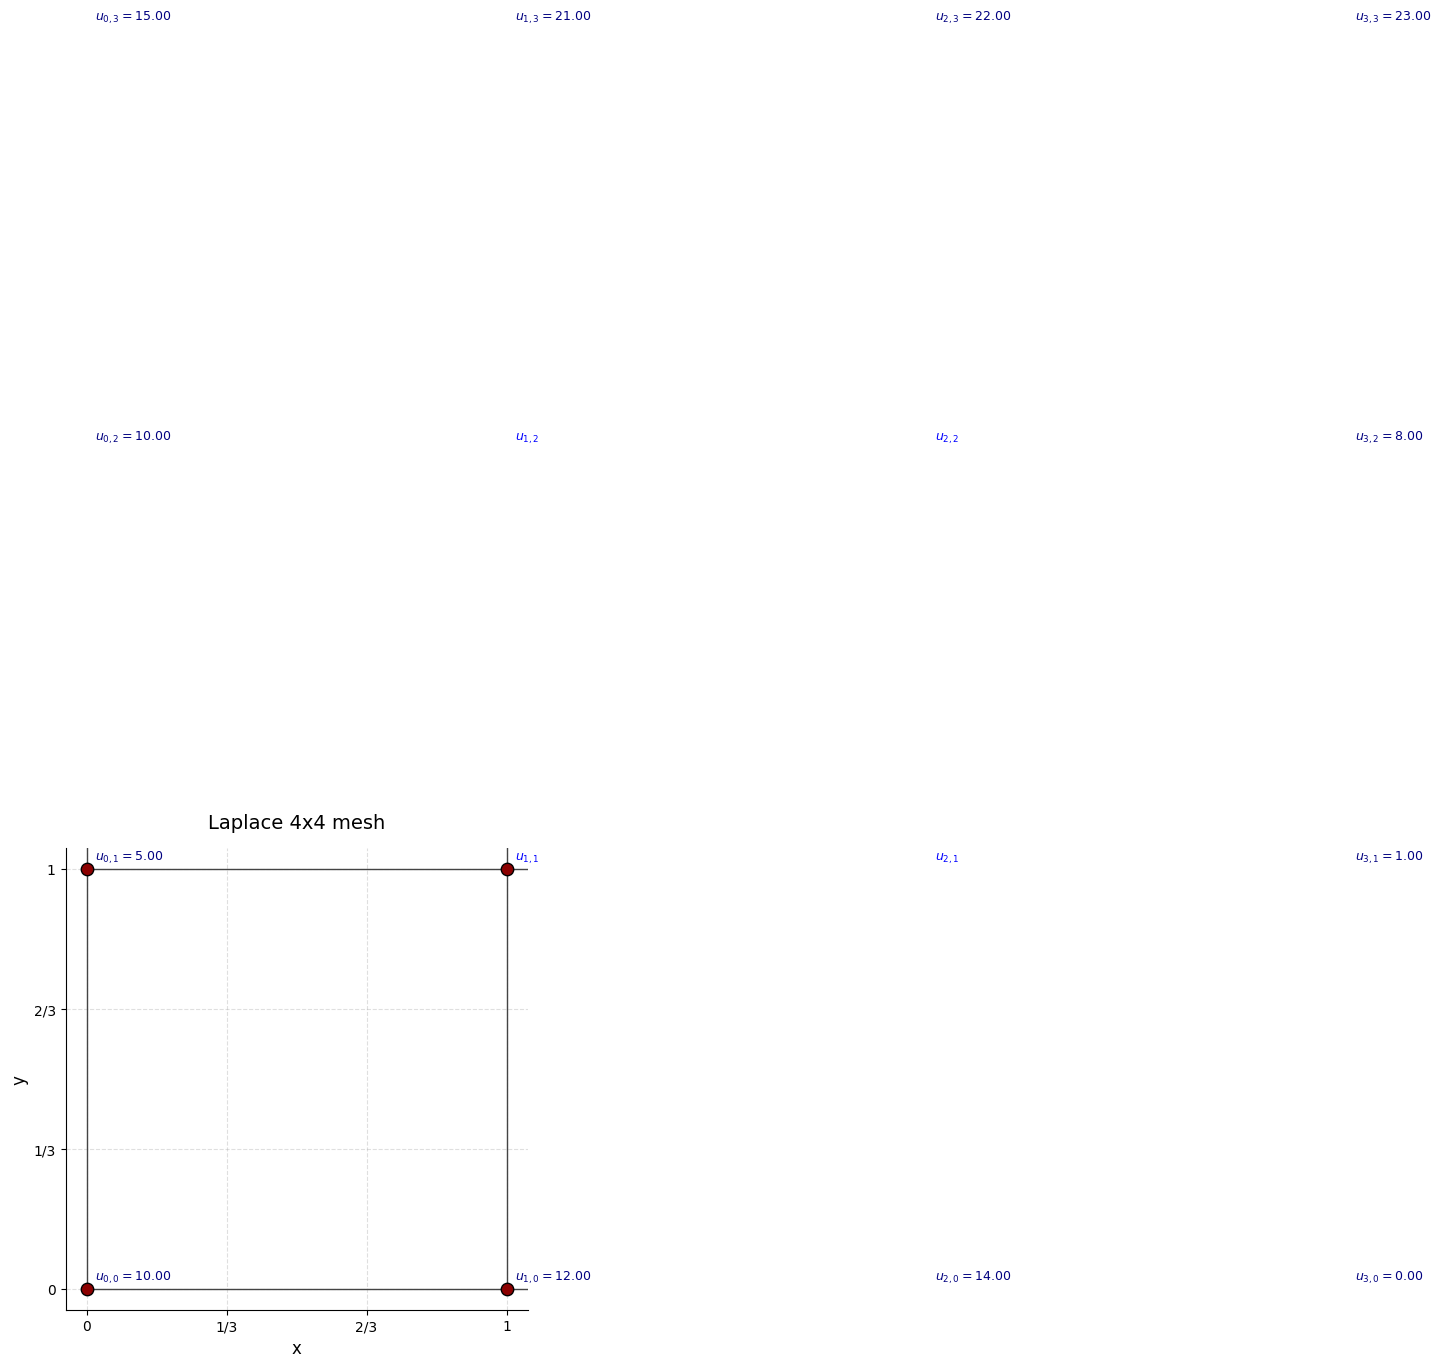

u array (i rows, j cols):
 [[10.  5. 10. 15.]
 [12.  0.  0. 21.]
 [14.  0.  0. 22.]
 [ 0.  1.  8. 23.]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# mesh
x = np.linspace(0, 1, 4)    # 4 nodes, h=1/3
y = np.linspace(0, 1, 4)
X, Y = np.meshgrid(x, y)

# boundary data
u = np.zeros((4, 4), float)
u[0, :] = 360*x          # bottom y=0  (row i=0)
u[-1, :] = 240*(1-x)     # top y=1 (row i=3)
u[:, 0] = 240*y          # left x=0  (col j=0)
u[:, -1] = 360*(1-y)     # right x=1 (col j=3)

# No interior solve yet: only boundary values
print("Boundary values for u on the square domain:")
print("bottom y=0 :", u[0, :])
print("top    y=1 :", u[-1, :])
print("left   x=0 :", u[:, 0])
print("right  x=1 :", u[:, -1])

# annotate, plot
plt.figure(figsize=(6,6))
for xi in x:
    plt.plot([xi]*len(y), y, color='#444444', lw=1)
for yi in y:
    plt.plot(x, [yi]*len(x), color='#444444', lw=1)
plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

for j in range(4):
    for i in range(4):
        if i in [0, 3] or j in [0, 3]:
            # boundary nodes with values (math convention i=row, j=col)
            plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                     f'$u_{{{i},{j}}}={u[i,j]:.2f}$',
                     color='navy', fontsize=9, weight='bold')
        else:
            # interior nodes shown by label only (no computed values yet)
            plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                     f'$u_{{{i},{j}}}$',
                     color='blue', fontsize=9, weight='bold')

plt.title('Laplace 4x4 mesh', fontsize=14, pad=14)
plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
plt.axis('square')
plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
plt.xticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
plt.yticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
for k in ['top','right']:
    plt.gca().spines[k].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("u array (i rows, j cols):\n", u)

This cell above shows only boundary values (as requested).

Math convention used: `i` = row (vertical), `j` = column (horizontal).

Standard 5-points formula:
$
\begin{align}
u_{i,j} = \frac{1}{4}\left(u_{i-1,j} + u_{i+1,j} + u_{i,j+1} + u_{i,j-1}\right)
\end{align}
$

Diagonal 5-points formula:
$
\begin{align}
u_{i,j} = \frac{1}{4}\left(u_{i-1,j+1} + u_{i+1,j-1} + u_{i+1,j+1} + u_{i-1,j-1}\right)
\end{align}
$

STD 5-point interior approximation:
[[  0. 120. 240. 360.]
 [ 80.  50. 120. 240.]
 [160.  80.  50. 120.]
 [240. 160.  80.   0.]]


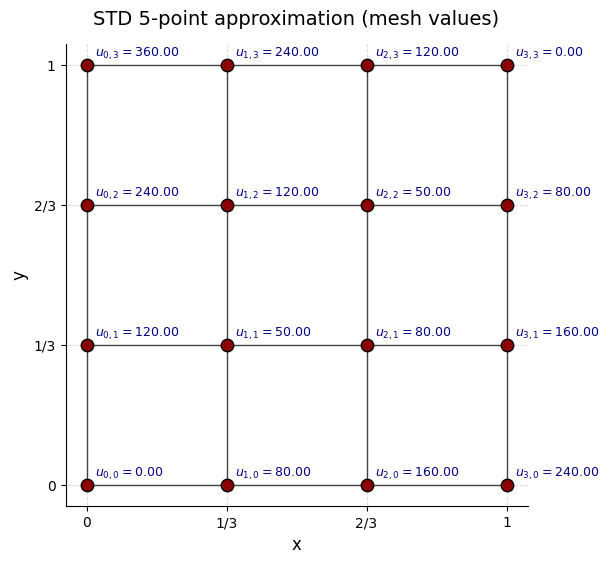

In [30]:
# Interior approximations from boundary values (math-style i=row, j=col)
# Standard 5-point: u[i,j] = 0.25*(u[i-1,j] + u[i+1,j] + u[i,j+1] + u[i,j-1])
# Diagonal 5-point: u[i,j] = 0.25*(u[i-1,j+1] + u[i+1,j-1] + u[i+1,j+1] + u[i-1,j-1])

# Choose approximation method: 'std' or 'diag'
method = 'std'  # Change to 'diag' for diagonal 5-point approximation

u_approx = u.copy()

for i in range(1, 3):
    for j in range(1, 3):
        if method == 'std':
            u_approx[i,j] = 0.25*(u[i-1,j] + u[i+1,j] + u[i,j+1] + u[i,j-1])
        elif method == 'diag':
            u_approx[i,j] = 0.25*(u[i-1,j+1] + u[i+1,j-1] + u[i+1,j+1] + u[i-1,j-1])

print(f'{method.upper()} 5-point interior approximation:')
print(u_approx)

def plot_mesh_values(u_matrix, title):
    plt.figure(figsize=(6,6))
    for xi in x:
        plt.plot([xi]*len(y), y, color='#444444', lw=1)
    for yi in y:
        plt.plot(x, [yi]*len(x), color='#444444', lw=1)
    plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

    for j in range(4):
        for i in range(4):
            plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                     f'$u_{{{i},{j}}}={u_matrix[i,j]:.2f}$',
                     color='navy', fontsize=9, weight='bold')

    plt.title(title, fontsize=14, pad=14)
    plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
    plt.axis('square')
    plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
    plt.xticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
    plt.yticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
    for k in ['top','right']:
        plt.gca().spines[k].set_visible(False)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

plot_mesh_values(u_approx, f'{method.upper()} 5-point approximation (mesh values)')


Gauss-Seidel solution after 2000 iterations:
[[  0.         120.         240.         360.        ]
 [ 80.         133.33333333 186.66666667 240.        ]
 [160.         146.66666667 133.33333333 120.        ]
 [240.         160.          80.           0.        ]]


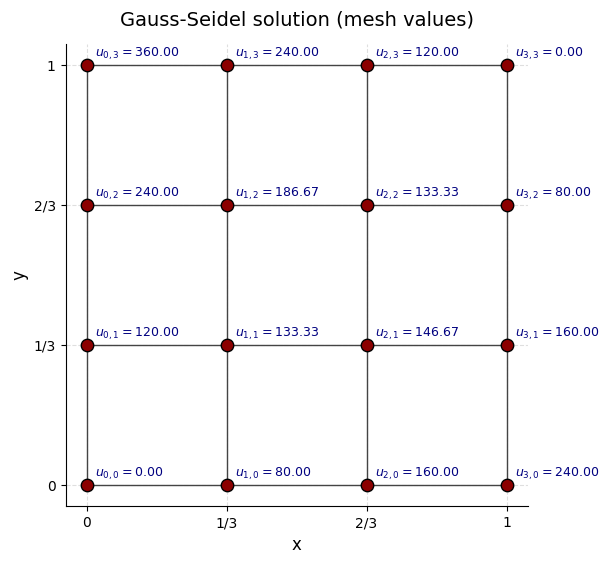

In [28]:
# Improve approximate solution with Gauss-Seidel iteration (in-place update)

u_gs = u_approx.copy()

for iteration in range(2000):
    for i in range(1, 3):
        for j in range(1, 3):
            u_gs[i,j] = 0.25*(u_gs[i-1,j] + u_gs[i+1,j] + u_gs[i,j+1] + u_gs[i,j-1])

print('Gauss-Seidel solution after 2000 iterations:')
print(u_gs)

plt.figure(figsize=(6,6))
for xi in x:
    plt.plot([xi]*len(y), y, color='#444444', lw=1)
for yi in y:
    plt.plot(x, [yi]*len(x), color='#444444', lw=1)
plt.scatter(X, Y, c='darkred', s=80, edgecolor='k', zorder=5)

for j in range(4):
    for i in range(4):
        plt.text(X[j,i]+0.02, Y[j,i]+0.02,
                 f'$u_{{{i},{j}}}={u_gs[i,j]:.2f}$',
                 color='navy', fontsize=9, weight='bold')

plt.title('Gauss-Seidel solution (mesh values)', fontsize=14, pad=14)
plt.xlabel('x', fontsize=12); plt.ylabel('y', fontsize=12)
plt.axis('square')
plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
plt.xticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
plt.yticks([0, 1/3, 2/3, 1], ['0', '1/3', '2/3', '1'])
for k in ['top','right']:
    plt.gca().spines[k].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

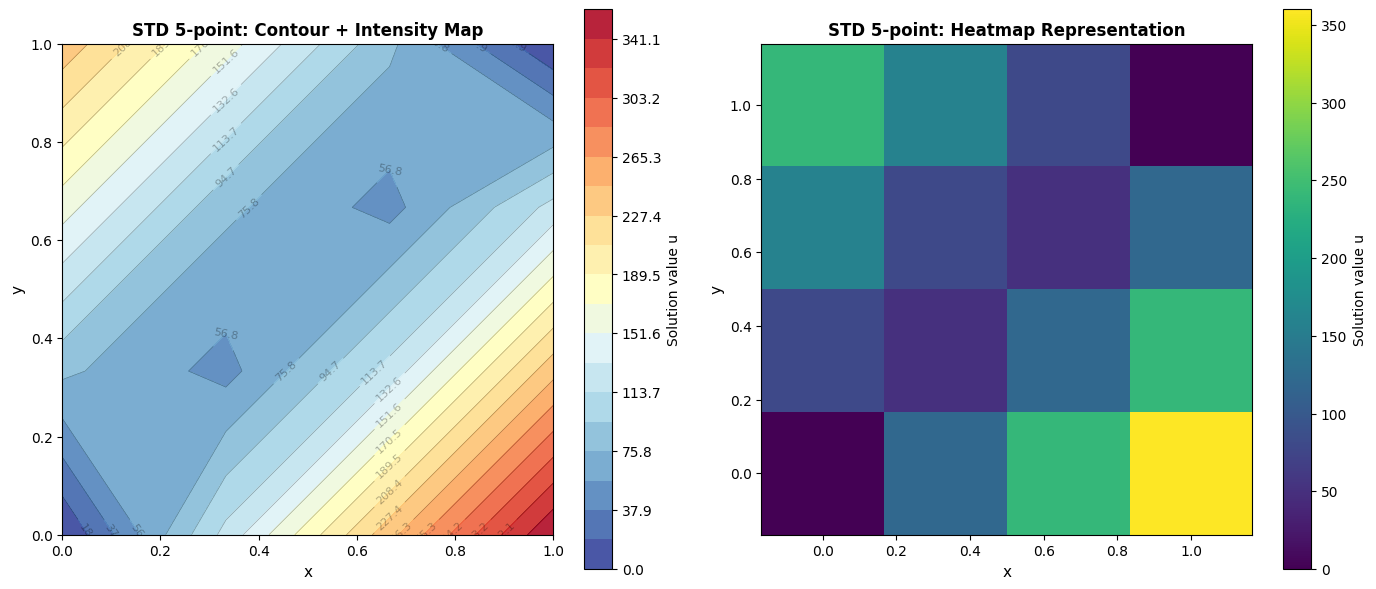

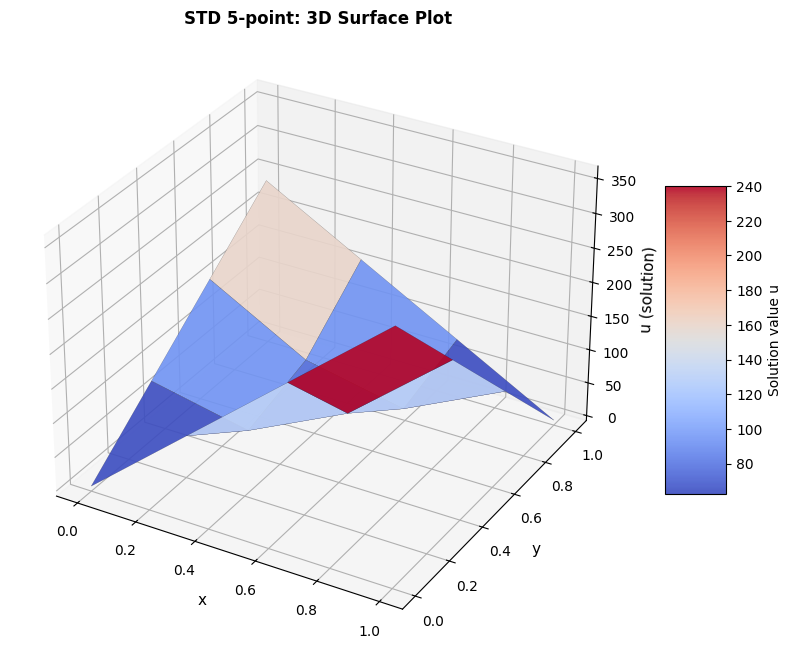

In [31]:

# Advanced visualization with color intensity (heatmap + contours)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Contourf plot with filled contours and color intensity
levels = np.linspace(u_approx.min(), u_approx.max(), 20)
contourf = ax1.contourf(X, Y, u_approx, levels=levels, cmap='RdYlBu_r', alpha=0.9)
contour = ax1.contour(X, Y, u_approx, levels=levels, colors='black', linewidths=0.5, alpha=0.3)
ax1.clabel(contour, inline=True, fontsize=8)
cbar1 = plt.colorbar(contourf, ax=ax1, label='Solution value u')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('y', fontsize=11)
ax1.set_title(f'{method.upper()} 5-point: Contour + Intensity Map', fontsize=12, weight='bold')
ax1.set_aspect('equal')

# Pcolormesh plot with finer color gradient
pcm = ax2.pcolormesh(X, Y, u_approx, cmap='viridis', shading='auto')
cbar2 = plt.colorbar(pcm, ax=ax2, label='Solution value u')
ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('y', fontsize=11)
ax2.set_title(f'{method.upper()} 5-point: Heatmap Representation', fontsize=12, weight='bold')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

# Surface-style 3D visualization option
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, u_approx, cmap='coolwarm', alpha=0.9, edgecolor='k', linewidth=0.1)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.set_zlabel('u (solution)', fontsize=11)
ax.set_title(f'{method.upper()} 5-point: 3D Surface Plot', fontsize=12, weight='bold')
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Solution value u')
plt.show()